In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

2026-03-13 00:50:22.981680: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def wavelet_distillation(distilled_image):
    # Perform a 2D Discrete Wavelet Transform
    # 'haar' is great for detecting intensity jumps (tumor boundaries)
    coeffs2 = pywt.dwt2(distilled_image, 'haar')
    LL, (LH, HL, HH) = coeffs2
    
    # LL is the 'Approximation' (the general shape)
    # LH, HL, HH are 'Details' (the edges/texture)
    
    # We can stack these to create a multi-resolution feature map
    # This gives the model 4x the 'logic' to work with
    wavelet_stack = np.block([
        [LL, LH],
        [HL, HH]
    ])
    
    return wavelet_stack

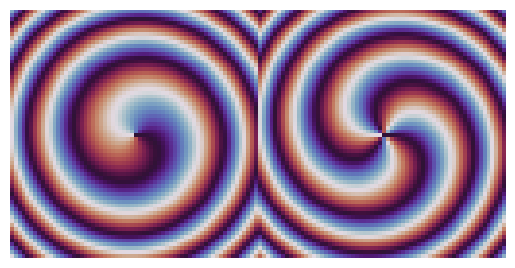

In [3]:
## Vortex map maker
# Topological Charges
m1 = 1 ; m2 = 3

xmax = 10       # f-plane max
dim = 64        # Image Size
dx = 2*xmax/dim # f-plane pixel size

# Get cylindrical coord
x = np.linspace(-xmax,xmax-dx,dim)
X,Y=np.meshgrid(x,x)
R2=(X**2+Y**2)
T = np.arctan2(Y,X)

# Lens Parameters
flambda=80
Lens = np.exp(-1j*R2/(flambda/10))

# Vortex phase modulation
V1 = np.exp(1j*(m1)*T) 
V2 = np.exp(1j*(m2)*T)
LG1=Lens*V1 ; LG2=Lens*V2

# Plot phase to make sure it's the right shape
plt.imshow(np.angle(np.hstack((LG1,LG2))),cmap='twilight')
plt.axis('off')
plt.show()

# This function takes a numpy array of size [num_images, dim, dim]
# and applies a vortex phase, an fft, and an absolute value to each image
def vort_THIS(A,LGA,LGB):
    length=A.shape[0]
    out=np.zeros((length,A.shape[1],A.shape[2]*2))
    for i in range(length):
        A1=np.abs(wavelet_distillation(np.exp(1j*A[i]*np.pi/2)*LGA)) ; A2=np.abs(wavelet_distillation(np.exp(1j*A[i]*np.pi/2)*LGB))
        # Our single layer NN requires domain restriction within [-1,1]
        A1=(A1-np.amin(A1))/np.amax(A1-np.amin(A1))*2-1    ; A2=(A2-np.amin(A2))/np.amax(A2-np.amin(A2))*2-1
        out[i]=np.hstack((A1,A2))
    return out

In [4]:
# Load the images

from tensorflow.keras.utils import to_categorical

DIM = 256           # Image dimension 
NUM_CLASSES = 4     # Number of tumor categories


def load_and_preprocess_data(data_dir):
    """Loads images as a dataset, converts to NumPy, and gets integer labels."""
    print(f"Loading data from: {data_dir}")

    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int', # Load as integers
        image_size=(DIM, DIM),
        batch_size=None, # Load all data into one tensor
        shuffle=False
    )
    # Convert to NumPy array
    # x shape will be (N, DIM, DIM, 3)
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    
    return x, y


# Load preprocessed training and testing data
x_train, y_train = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Training/')
x_test, y_test = load_and_preprocess_data('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Testing/')

# Number of training and testing samples
n_train, n_test = x_train.shape[0], x_test.shape[0]

print(f"\nTraining Samples: {n_train}, Testing Samples: {n_test}")


def convert_to_grayscale_batch(images_rgb_batch, N_samples):
    """Converts a batch of (N, H, W, 3) images to (N, H, W, 1) grayscale using cv2."""
    # Initialize an empty array for the final grayscale data
    images_gray_batch = np.empty((N_samples, DIM, DIM, 1), dtype=np.float32)

    # Loop through the batch and apply the conversion image-by-image
    for i in tqdm(range(N_samples), desc="Converting to Grayscale"):
        # OpenCV needs uint8 format (0-255)
        image_uint8 = images_rgb_batch[i].astype(np.uint8)
        
        # Perform the conversion (Output is 2D: H x W)
        gray_2d = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
        
        # Add the channel dimension back and store (Shape: H x W x 1)
        images_gray_batch[i] = gray_2d[..., np.newaxis]
        
    return images_gray_batch

# Normalize to [0, 1] range
x_train = convert_to_grayscale_batch(x_train, n_train) / 255.0
x_test = convert_to_grayscale_batch(x_test, n_test) / 255.0


def downsample_batch(images_batch, target_dim):
    """Resizes a batch of images from (N, 256, 256) to (N, target_dim, target_dim)."""
    print(f"Downsampling images from {images_batch.shape[1]}x{images_batch.shape[2]} to {target_dim}x{target_dim}...")
    
    downsampled_images = np.empty((images_batch.shape[0], target_dim, target_dim), dtype=np.float32)
    
    # Loop and resize each image
    for i in tqdm(range(images_batch.shape[0]), desc="Resizing Images"):
        # The INTER_AREA interpolation is best for shrinking images
        downsampled_images[i] = cv2.resize(images_batch[i], 
                                           (target_dim, target_dim), 
                                           interpolation=cv2.INTER_AREA)
    return downsampled_images


DIM = 64  # New dimension after downsampling

# X_train_vort_input is now (N, 32, 32)
x_train = downsample_batch(x_train, DIM)
x_test = downsample_batch(x_test, DIM)


# Lablels
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Training/
Found 5712 files belonging to 4 classes.


I0000 00:00:1773388227.713817   20401 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-03-13 00:50:36.333787: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading data from: /mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Brain Tumor Dataset/Testing/
Found 1311 files belonging to 4 classes.


2026-03-13 00:50:42.067651: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-13 00:50:43.994723: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Training Samples: 5712, Testing Samples: 1311


Converting to Grayscale: 100%|██████████| 1311/1311 [00:00<00:00, 5924.51it/s]


Downsampling images from 256x256 to 64x64...


Resizing Images: 100%|██████████| 5712/5712 [00:00<00:00, 15726.81it/s]


Downsampling images from 256x256 to 64x64...


Resizing Images: 100%|██████████| 1311/1311 [00:00<00:00, 14420.37it/s]


In [7]:
# --- ROBUST CUSTOM OBJECTS DICTIONARY ---
# We map all possible conflicting strings (keys) to their current TensorFlow objects (values).
CUSTOM_OBJECTS = {
    # 1. Metrics (Likely Source of Error)
    'keras.metrics.MSE': tf.keras.metrics.MeanSquaredError(),
    'MSE': tf.keras.metrics.MeanSquaredError(),
    'mse': tf.keras.metrics.MeanSquaredError(),
    
    # 2. Loss Functions (Possible Source of Error)
    'mean_squared_error': tf.keras.losses.MeanSquaredError(),
    
    # 3. Optimizers (Needed if you want to resume training, though not needed for prediction)
    'rmsprop': tf.keras.optimizers.RMSprop() 
}


# ---Loading Loop (Adjust the path as needed) ---

# IMPORTANT: I'm using the fixed path structure from our previous conversation.
model_path = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/Wavelet/speckles.keras' 

reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)

In [6]:
# Put the dataset through the vortex mask and Fourier Transform
transformed_xtrain=vort_THIS(x_train, LG1, LG2)
transformed_xtest=vort_THIS(x_test, LG1, LG2)



In [8]:
DIM = 64

N_train = 5712

recon_tumor = reconstruction_model.predict(
    transformed_xtrain.reshape(N_train, 2 * DIM**2)
).reshape(N_train, DIM, DIM)

2026-03-13 00:51:41.973903: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ae34c003cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-13 00:51:41.973944: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-03-13 00:51:41.997027: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-03-13 00:51:42.547545: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 60 bytes spill stores, 60 bytes spill loads



 37/179 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

I0000 00:00:1773388302.923044   20522 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [11]:
def calculate_full_dataset_dwt_fi_FIXED(X_train, y_train, epsilon=1e-4):
    y_ints = np.argmax(y_train, axis=1)
    class_names = {0: 'Glioma', 1: 'Meningioma', 2: 'No_Tumor', 3: 'Pituitary'}
    
    # 1. Properly create the DWT Anchor from the Average Healthy Brain
    healthy_images = X_train[y_ints == 2]
    healthy_mean_spatial = np.mean(healthy_images, axis=0).reshape(64, 64)
    
    # You MUST perform the DWT on the mean image to get the anchor coefficients
    coeffs_healthy = pywt.dwt2(healthy_mean_spatial, 'haar')
    LL_h, (LH_h, HL_h, HH_h) = coeffs_healthy 

    # 2. Storage for FI results
    fi_scores = {c: [] for c in range(4)}

    for i in range(len(X_train)):
        img = X_train[i].reshape(64, 64)
        label = y_ints[i]
        
        # Perform DWT on the individual reconstructed image
        coeffs_img = pywt.dwt2(img, 'haar')
        LL_i, (LH_i, HL_i, HH_i) = coeffs_img
        
        # Calculate FI across the Detail Bands (LH, HL, HH)
        # These bands capture the high-frequency vortex-tumor interaction
        total_fi = 0
        for band_img, band_h in [(LH_i, LH_h), (HL_i, HL_h), (HH_i, HH_h)]:
            numerator = (band_img - band_h)**2
            denominator = np.abs(band_img) + epsilon
            total_fi += np.sum(numerator / denominator)
        
        fi_scores[label].append(total_fi)

    # 3. Calculate Stats
    stats = {}
    for c, scores in fi_scores.items():
        stats[class_names[c]] = {
            'Mean_FI': np.mean(scores),
            'Std_FI': np.std(scores),
            'CV': np.std(scores) / np.mean(scores) if np.mean(scores) != 0 else 0
        }
    
    return stats

# Execute on your reconstructed DWT dataset
FI_DWT = calculate_full_dataset_dwt_fi_FIXED(recon_tumor, y_train)
print(FI_DWT)

{'Glioma': {'Mean_FI': np.float32(527.43256), 'Std_FI': np.float32(129.42227), 'CV': np.float32(0.24538165)}, 'Meningioma': {'Mean_FI': np.float32(611.8064), 'Std_FI': np.float32(152.63852), 'CV': np.float32(0.24948826)}, 'No_Tumor': {'Mean_FI': np.float32(758.58386), 'Std_FI': np.float32(242.12184), 'CV': np.float32(0.3191761)}, 'Pituitary': {'Mean_FI': np.float32(600.5715), 'Std_FI': np.float32(139.04985), 'CV': np.float32(0.23152924)}}


In [13]:

# Calculate the Coefficient of Variation (CV) for each class in the DWT and FFT FI results

CV_DWT_0 = FI_DWT['Glioma']['Std_FI'] / FI_DWT['Glioma']['Mean_FI']
CV_DWT_1 = FI_DWT['Meningioma']['Std_FI'] / FI_DWT['Meningioma']['Mean_FI']
CV_DWT_2 = FI_DWT['No_Tumor']['Std_FI'] / FI_DWT['No_Tumor']['Mean_FI']
CV_DWT_3 = FI_DWT['Pituitary']['Std_FI'] / FI_DWT['Pituitary']['Mean_FI']

print(f"Coefficient of Variation (CV) for DWT FI:")
print(f"  Class 0: {CV_DWT_0:.4f}")
print(f"  Class 1: {CV_DWT_1:.4f}")
print(f"  Class 2: {CV_DWT_2:.4f}")
print(f"  Class 3: {CV_DWT_3:.4f}")



Coefficient of Variation (CV) for DWT FI:
  Class 0: 0.2454
  Class 1: 0.2495
  Class 2: 0.3192
  Class 3: 0.2315


In [17]:
def generate_fi_heatmaps_dwt(X_train, y_train, epsilon=1e-4):
    y_ints = np.argmax(y_train, axis=1)
    class_names = {0: 'Glioma', 1: 'Meningioma', 2: 'No_Tumor', 3: 'Pituitary'}
    
    # 1. Create the DWT "Anchor" using the Average Healthy Brain
    healthy_images = X_train[y_ints == 2]
    healthy_mean = np.mean(healthy_images, axis=0).reshape(64, 64)
    
    # We use the Approximation coefficients (LL) for the baseline
    coeffs_healthy = pywt.dwt2(healthy_mean, 'haar')
    LL_healthy, (LH, HL, HH) = coeffs_healthy 

    # 2. Storage for the 32x32 matrices (DWT halves the dimension)
    fi_matrices = {c: [] for c in range(4)}

    for i in range(len(X_train)):
        img = X_train[i].reshape(64, 64)
        label = y_ints[i]
        
        # Perform 2D DWT on individual image
        coeffs_img = pywt.dwt2(img, 'haar')
        LL_img, _ = coeffs_img
        
        # Calculate Local FI Matrix in the DWT Domain
        # FI = (Subband_Img - Subband_Healthy_Mean)^2 / (Subband_Img + epsilon)
        numerator = (LL_img - LL_healthy)**2
        denominator = np.abs(LL_img) + epsilon
        local_fi_matrix = numerator / denominator
        
        fi_matrices[label].append(local_fi_matrix)

    # 3. Average the matrices per class
    mean_heatmaps = {}
    for c, matrices in fi_matrices.items():
        mean_heatmaps[class_names[c]] = np.mean(matrices, axis=0)
    
    return mean_heatmaps

# Execute
fi_maps_dwt = generate_fi_heatmaps_dwt(recon_tumor, y_train)

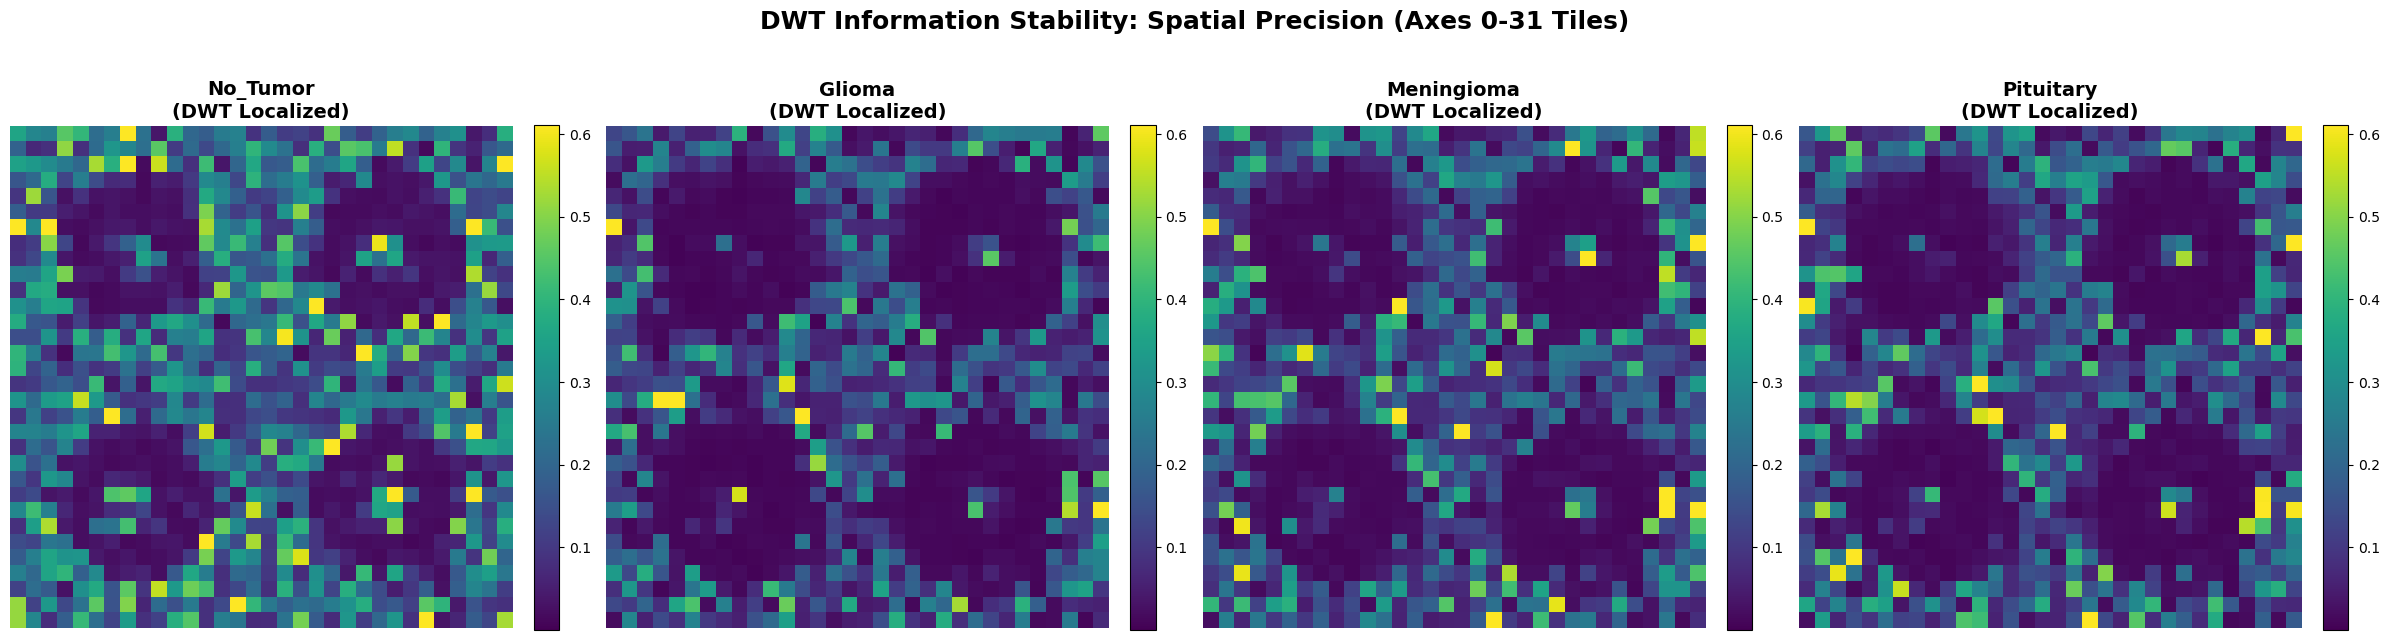

In [18]:
# 4x1 Subplot for DWT (The "Spatial-Frequency" Map)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
order = ['No_Tumor', 'Glioma', 'Meningioma', 'Pituitary']
all_values = np.concatenate([fi_maps_dwt[cls].flatten() for cls in order])
global_vmax = np.percentile(all_values, 99)

for i, cls in enumerate(order):
    # Using your convention: Cap at 99th percentile for better contrast
    v_max = np.percentile(fi_maps_dwt[cls], 99)
    
    im = axes[i].imshow(fi_maps_dwt[cls], cmap='viridis', vmin=1e-5, vmax=global_vmax)
    
    # Title showing Class + RSD (Relative Standard Deviation) for Statistical Rigor
    axes[i].set_title(f'{cls}\n(DWT Localized)', fontsize=14, fontweight='bold')
    axes[i].axis('off') 
    
    # Add a colorbar to each subplot
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle('DWT Information Stability: Spatial Precision (Axes 0-31 Tiles)', fontsize=18, y=1.08, fontweight='bold')
plt.tight_layout()

plt.show()